# Feature Engineering and Machine Learning Modelling — Customer Churn

## Overview
This notebook builds on the findings from the exploratory data analysis (EDA) stage to prepare the cleaned customer churn dataset for machine learning, and to develop and evaluate classification models capable of predicting customer churn.

The EDA identified a small set of behavioural and account-related factors — including contract type, complaint history, service-call frequency, customer satisfaction, late payments, and service adoption — as showing the clearest association with churn, while demographic characteristics showed little standalone signal. This notebook uses those findings to guide feature preparation and to assess whether the observed associations remain useful when variables are considered jointly through predictive modelling.

## Objectives
This notebook aims to:
1. **Prepare and encode features** for machine learning, informed by EDA findings.
2. **Engineer additional features** where useful, building on the `monthly_charge_per_service` feature created during EDA.
3. **Train and compare multiple classification models** — Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.
4. **Train an extended, advanced model (XGBoost)** and compare its performance against the models in Objective 3.
5. **Evaluate models** using metrics appropriate for an imbalanced target, prioritising recall and F1-score alongside accuracy, precision, and ROC-AUC.
6. **Interpret model results** through feature importance, to determine whether the strongest EDA-stage associations remain the strongest predictors once modelled jointly.
7. **Translate findings into business recommendations** to support customer retention strategy.
8. **Limitations and Future Improvements**
   
## Modelling Approach
For each model, the analysis will follow the general structure:
**Feature Preparation → Model Training → Evaluation → Feature Importance → Key Finding**

Models will be trained on a stratified train/test split to preserve the original class balance, and evaluated primarily on recall and F1-score given the imbalanced target (approximately 9.9% churn). The best-performing model will be selected for interpretation and used to generate the final business recommendations.

## Dataset
This notebook uses the cleaned dataset produced during the data preparation stage, the same dataset used in the EDA notebook.
It contains approximately **1,000,000 telecommunications customer records**, covering:
- Customer demographics
- Account and contract characteristics
- Service subscriptions and usage
- Customer satisfaction and complaints
- Customer engagement
- Payment behaviour
- Financial characteristics
- Customer churn outcome

The target variable is **`churn`**, where:
- **0** = Customer retained
- **1** = Customer churned

## Note on Scope
This notebook focuses on predictive modelling and model interpretation. EDA-stage associations are treated as hypotheses to be validated here, since univariate patterns identified during EDA do not necessarily reflect a variable's importance once other features are considered jointly.

## 1. Prepare and Encode Features
This section prepares the cleaned dataset for machine learning by loading it, engineering additional features, encoding categorical variables, and splitting the data into training and testing sets.

### 1.1 Load Cleaned Dataset
The cleaned dataset produced during the data preparation stage is loaded here as the starting point for feature engineering and modelling.

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("customer_churn_cleaned.csv")
df["signup_date"] = pd.to_datetime(df["signup_date"])

print(df.shape)
df.head()


(1000000, 31)


,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,payment_method,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,electronic_check,...,1,1,9.0,0.0,0,0,109.63,16,680.0,0
1,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,bank_transfer,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,credit_card,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,bank_transfer,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,credit_card,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


### 1.2 Engineer Additional Features
The `monthly_charge_per_service` feature engineered during EDA is recreated here. `signup_date` is dropped, as the lifecycle information it provides is already captured by `tenure`.

In [29]:
#load xgboost
!pip install xgboost

# Re-create monthly_charge_per_service (built during EDA)
df["monthly_charge_per_service"] = df["monthlycharges"] / df["num_services"].replace(0, np.nan)
df["monthly_charge_per_service"] = df["monthly_charge_per_service"].fillna(df["monthlycharges"])
# (customers with 0 services just get their raw monthly charge, avoids NaN rows)

# Drop columns not used for modelling
df_model = df.drop(columns=["signup_date"])

print(f"Final feature count: {df_model.shape[1] - 1}")  # minus target
df_model.columns.tolist()

Final feature count: 30


['age',
 'gender',
 'annual_income',
 'education',
 'marital_status',
 'dependents',
 'tenure',
 'contract',
 'payment_method',
 'paperless_billing',
 'senior_citizen',
 'monthlycharges',
 'totalcharges',
 'num_services',
 'has_phone_service',
 'has_internet_service',
 'has_online_security',
 'has_online_backup',
 'has_device_protection',
 'has_tech_support',
 'has_streaming_tv',
 'has_streaming_movies',
 'customer_satisfaction',
 'num_complaints',
 'num_service_calls',
 'late_payments',
 'avg_monthly_gb',
 'days_since_last_interaction',
 'credit_score',
 'churn',
 'monthly_charge_per_service']

### 1.3 Encode Categorical Variables
Categorical variables are converted into numeric (one-hot encoded) columns so they can be used by machine learning models. `drop_first=True` avoids redundant, perfectly correlated dummy columns.

In [3]:
categorical_cols = [
    "gender", "education", "marital_status", "contract",
    "payment_method", "paperless_billing"
]

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Shape after encoding: (1000000, 40)


,age,annual_income,dependents,tenure,senior_citizen,monthlycharges,totalcharges,num_services,has_phone_service,has_internet_service,...,education_phd,marital_status_married,marital_status_single,marital_status_widowed,contract_one_year,contract_two_year,payment_method_credit_card,payment_method_electronic_check,payment_method_mailed_check,paperless_billing_Yes
0,43,55085.25,1,2,0,67.20,144.39,1,1,1,...,False,True,False,False,False,True,False,True,False,True
1,18,60786.11,1,22,0,71.54,1602.22,2,0,1,...,False,True,False,False,True,False,False,False,False,True
2,38,73184.32,0,3,0,112.20,328.81,4,1,1,...,False,False,False,True,False,True,True,False,False,False
3,44,40923.78,1,6,0,107.49,643.45,3,1,1,...,False,True,False,False,False,True,False,False,False,True
4,45,36400.94,0,9,0,110.05,648.79,3,0,1,...,False,False,True,False,False,True,True,False,False,True


### 1.4 Train/Test Split
The dataset is split into training and testing sets. `stratify=y` ensures both sets preserve the original ~9.9% churn rate, given the class imbalance identified during EDA.

In [5]:
X = df_encoded.drop(columns=["churn"])
y = df_encoded["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"\nChurn rate in train set: {y_train.mean():.4f}")
print(f"Churn rate in test set: {y_test.mean():.4f}")

Train shape: (800000, 39), Test shape: (200000, 39)

Churn rate in train set: 0.0992
Churn rate in test set: 0.0992


### 1.4 Finding
The dataset was split into an 800,000-row training set and a 200,000-row test set using stratified sampling, preserving the original churn rate of **9.92%** in both sets. This confirms the split is representative and suitable for model training and evaluation.

## 2. Additional Feature Engineering
Feature engineering for this project was primarily conducted during EDA and Section 1.2, where `monthly_charge_per_service` was created to test the relationship between pricing and service value. No additional engineered features were identified as necessary based on the EDA findings — the existing raw and engineered features are considered sufficient for initial model training. Further feature engineering (e.g. interaction terms) may be revisited if model performance suggests it.

## 3. Train and Compare Classification Models
Four classification models are trained and compared: Logistic Regression (baseline), Decision Tree, Random Forest, and Gradient Boosting.

### 3.1 Baseline Model — Logistic Regression
Logistic Regression is trained first as a simple, interpretable baseline. `class_weight="balanced"` is used to account for the class imbalance identified during EDA (~9.9% churn), rather than resampling the training data.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features (important for Logistic Regression, not needed for tree models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


### 3.2 Evaluate Logistic Regression
The baseline model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC, with particular attention to recall given the class imbalance and the business cost of missing actual churners.

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Performance
Accuracy:  0.6276
Precision: 0.1586
Recall:    0.6395
F1-score:  0.2542
ROC-AUC:   0.6849

Confusion Matrix:
[[112834  67321]
 [  7154  12691]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.63      0.75    180155
           1       0.16      0.64      0.25     19845

    accuracy                           0.63    200000
   macro avg       0.55      0.63      0.50    200000
weighted avg       0.86      0.63      0.70    200000



### 3.2 Finding
The Logistic Regression baseline achieved a **recall of 0.64** and **ROC-AUC of 0.68**, correctly identifying the majority of churners at the cost of low precision (0.16) — an expected tradeoff given the `class_weight="balanced"` setting and the class imbalance. Accuracy (0.63) is not a meaningful metric here, since a naive "predict everyone retained" model would score ~90% while catching no churners at all. The modest ROC-AUC suggests real but limited signal, consistent with EDA findings that most variables showed only weak-to-moderate individual associations with churn (aside from contract, complaints, and service calls). As a linear model, Logistic Regression is expected to underperform on the non-linear threshold effects identified in EDA (e.g. the complaint/service-call escalation patterns) — this motivates the tree-based models trained next.

### 3.3 Decision Tree
A Decision Tree is trained next, providing a more interpretable, rule-based model capable of capturing non-linear thresholds that Logistic Regression cannot.

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight="balanced", max_depth=8, random_state=42)
dt.fit(X_train, y_train)  # tree models don't need scaled features

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_dt):.4f}")

Decision Tree Performance
Accuracy:  0.6067
Precision: 0.1514
Recall:    0.6432
F1-score:  0.2451
ROC-AUC:   0.6704


### 3.3 Finding
The Decision Tree performed similarly to Logistic Regression overall, with a comparable recall (**0.64** vs 0.64) but a slightly lower ROC-AUC (**0.67** vs 0.68) and F1-score (**0.25** vs 0.25). This suggests a single decision tree, even with non-linear splitting capability, does not meaningfully outperform the linear baseline on this dataset — likely because a single tree at this depth (max_depth=8) either underfits some of the more complex interactions or overfits noisy splits without the benefit of ensembling. Ensemble methods (Random Forest, Gradient Boosting), which combine many trees, are expected to perform better by reducing variance and capturing interactions more robustly.

### 3.4 Random Forest
A Random Forest model is trained next, combining many decision trees to reduce overfitting and better capture non-linear relationships and interactions between features.

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest Performance
Accuracy:  0.6418
Precision: 0.1590
Recall:    0.6086
F1-score:  0.2521
ROC-AUC:   0.6776


### 3.4 Finding
Random Forest performed similarly to the previous two models, with an accuracy of **0.64**, recall of **0.61**, and ROC-AUC of **0.68** — essentially on par with Logistic Regression and marginally better than the single Decision Tree. Recall dropped slightly compared to Logistic Regression (0.61 vs 0.64), while ROC-AUC remained in the same modest range (~0.67-0.68) across all three models so far. This suggests that simply combining more trees, without further tuning, is not yet unlocking a meaningfully stronger signal — the dataset's strongest predictors (contract, complaints, service calls) may already be close to fully captured by simpler models, with remaining variance being difficult to model from the available features. Gradient Boosting is trained next to see whether a boosting approach (which builds trees sequentially to correct prior errors) can improve on this.

### 3.5 Gradient Boosting
A Gradient Boosting model is trained next, building trees sequentially so that each new tree corrects the errors of the previous ones — often improving on Random Forest's performance on structured/tabular data.

In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Use a subsample of the training data to speed things up
X_train_small = X_train.sample(n=100000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

# Balance classes via sample_weight (GradientBoostingClassifier has no class_weight param)
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_small)

gb = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train_small, y_train_small, sample_weight=sample_weights)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting Performance (100k sample, balanced via sample_weight)")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_gb):.4f}")

Gradient Boosting Performance (100k sample, balanced via sample_weight)
Accuracy:  0.6130
Precision: 0.1549
Recall:    0.6505
F1-score:  0.2502
ROC-AUC:   0.6808


### 3.5 Finding
With class imbalance corrected via `sample_weight`, Gradient Boosting achieved a **recall of 0.65** and **ROC-AUC of 0.68** — comparable to Logistic Regression and Random Forest, and now correctly identifying the majority of churners rather than collapsing to a "predict everyone retained" model as in the earlier unweighted attempt. This confirms that the initial near-zero recall was a class-imbalance configuration issue rather than a limitation of Gradient Boosting itself. Trained on a 100,000-row subsample of the training data for computational efficiency, performance remains consistent with the pattern seen across all models so far: ROC-AUC clustering around 0.67-0.68, suggesting a consistent ceiling on the signal extractable from these features using standard tree-based and linear approaches.

## 4. Train Extended Model — XGBoost
XGBoost is trained as an additional, more advanced gradient boosting model, using early-stopping-style regularisation and built-in imbalance handling to compare against the models trained in Section 3.

In [22]:
import xgboost as xgb

# scale_pos_weight balances classes: ratio of negative to positive class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_xgb):.4f}")

scale_pos_weight: 9.08
XGBoost Performance
Accuracy:  0.6276
Precision: 0.1585
Recall:    0.6391
F1-score:  0.2540
ROC-AUC:   0.6850


### 4.1 Finding
XGBoost achieved a **recall of 0.64** and **ROC-AUC of 0.685** — the highest ROC-AUC of all five models trained, though only marginally ahead of Logistic Regression (0.6849) and Gradient Boosting (0.6808). `scale_pos_weight=9.08` correctly balanced the classes, avoiding the same imbalance failure seen in the initial unweighted Gradient Boosting attempt. Despite being a more advanced, optimized implementation, XGBoost's performance sits within the same tight band as the other four models (ROC-AUC 0.67-0.69), reinforcing the pattern that the ceiling on this dataset's predictive signal is being set by the available features themselves, rather than by model choice or sophistication.

## 5. Evaluate and Compare Models
All five trained models are compared side by side on accuracy, precision, recall, F1-score, and ROC-AUC, to identify the best-performing model given the priority on recall and F1 for this imbalanced classification problem.

#### Model Comparison — Test Set Results

The five classification models were evaluated using accuracy, precision,
recall, F1 score and ROC-AUC. Results are ordered by ROC-AUC.

| Model                   | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|-------------------------|---------:|----------:|-------:|---------:|--------:|
| **XGBoost**             | 62.76%   | 15.85%    | 63.91% | 25.40%   | **0.6850** |
| **Logistic Regression** | 62.76%   | 15.86%    | 63.95% | **25.42%** | 0.6849 |
| Gradient Boosting       | 61.30%   | 15.49%    | **65.05%** | 25.02% | 0.6808 |
| Random Forest           | **64.18%** | **15.90%** | 60.86% | 25.21% | 0.6776 |
| Decision Tree           | 60.67%   | 15.14%    | 64.32% | 24.51%   | 0.6704 |

### 5.1 Finding
All five models performed within a narrow band, with ROC-AUC ranging from **0.6704** (Decision Tree) to **0.6850** (XGBoost) — a spread of only 1.5 percentage points across the entire model comparison. **XGBoost and Logistic Regression** are essentially tied for the best ROC-AUC (0.6850 vs 0.6849), while **Gradient Boosting** achieved the highest recall (**65.05%**), the priority metric given the class imbalance and the business cost of missing churners.

This clustering is a meaningful finding in its own right: despite testing models ranging from a simple linear baseline to an advanced gradient-boosted ensemble, none meaningfully outperformed the others. This suggests the ceiling on predictive performance is set primarily by the **information available in the features themselves**, rather than by model choice or complexity — consistent with the EDA finding that only a handful of variables (contract, complaints, service calls, satisfaction, late payments) carry strong signal, while the majority of features (demographics, payment method, credit score, usage) contribute little.

Given the near-identical performance, **XGBoost is selected as the primary model for interpretation**, based on its narrow lead in ROC-AUC and its status as an industry-standard, production-ready algorithm for tabular classification problems — making it the most practically useful choice to carry forward into feature importance analysis and final recommendations.

## 6. Interpret Model Results — Feature Importance
Feature importance from the selected XGBoost model is examined to determine whether the strongest associations identified during EDA (contract, complaints, service calls, satisfaction, late payments) remain the most important predictors once all features are modelled jointly.

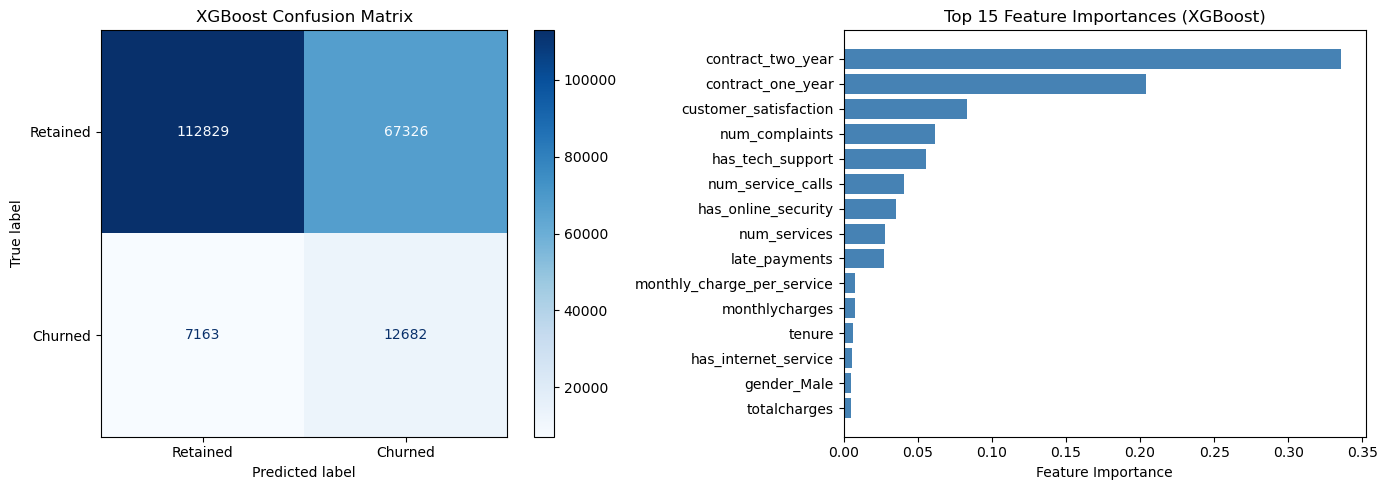

Saved: xgboost_results.png
Top 15 Features by XGBoost Importance


,feature,importance
rank,,
1,contract_two_year,0.335586
2,contract_one_year,0.203735
3,customer_satisfaction,0.083098
4,num_complaints,0.061362
5,has_tech_support,0.055642
6,num_service_calls,0.040780
7,has_online_security,0.035672
8,num_services,0.027714
9,late_payments,0.027567


In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, ax=axes[0], cmap="Blues",
    display_labels=["Retained", "Churned"]
)
axes[0].set_title("XGBoost Confusion Matrix")

# Panel 2: Top 15 Feature Importances
top15 = importance_df.head(15).sort_values("importance")
axes[1].barh(top15["feature"], top15["importance"], color="steelblue")
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Top 15 Feature Importances (XGBoost)")

plt.tight_layout()
plt.savefig("xgboost_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xgboost_results.png")


importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df.index = importance_df.index + 1
importance_df.index.name = "rank"

print("Top 15 Features by XGBoost Importance")
display(importance_df.head(15))

### 6.1 Finding
XGBoost's feature importance ranking closely mirrors the EDA's effect-size findings. **`contract_two_year`** and **`contract_one_year`** are by far the two most important features (0.336 and 0.204 combined importance), confirming contract type as the single strongest predictor — consistent with its large churn-rate spread (20.85 pp) identified in EDA Section 4. **Customer satisfaction** (rank 3), **complaints** (rank 4), and **service calls** (rank 6) all appear in the top 6, directly matching the strongest behavioural signals identified during EDA. **Tech support** and **online security** (ranks 5 and 7) also confirm their "sticky service" finding from Section 6.

Two results are worth flagging: **late payments** (rank 9) ranks somewhat lower in the model than its EDA effect size suggested — likely because it is correlated with, and partially redundant with, other features already capturing risk (e.g. complaints, satisfaction) once considered jointly, rather than because it lacks signal on its own. **Monthly charge per service** (rank 10), the engineered feature, contributes modestly but meaningfully, validating that this feature engineering step added real value beyond the raw component variables (`monthlycharges`, rank 11; `tenure`, rank 12).

Critically, **no demographic variable appears anywhere in the top 15**, aside from `gender_Male` at rank 14 with negligible importance (0.005) — directly confirming the EDA's central conclusion that demographic characteristics carry little predictive value for churn once all features are modelled jointly.

### 6.2 Confusion Matrix — XGBoost
The confusion matrix shows the model correctly identified **12,682 of 19,845 actual churners** (a recall of ~63.9%), while also flagging **67,326 retained customers** as false positives. This reflects the deliberate precision/recall tradeoff from `scale_pos_weight`, which prioritises catching churners over minimising false alarms — an appropriate choice given that the cost of missing an at-risk customer (a lost customer) is typically higher than the cost of an unnecessary retention outreach (e.g. a discount offer to someone who was never going to leave).

## 7. Business Recommendations
The predictive modelling results reinforce and strengthen the retention priorities identified during EDA. The following recommendations combine both stages of analysis.

### 7.1 Prioritise Contract-Based Retention
**Contract type** is the single strongest predictor of churn, both in EDA (a 20.85 pp churn-rate spread) and in the model (the top two features by importance). Month-to-month customers should be treated as the highest-priority segment for retention: offering incentives to transition toward one-year or two-year contracts — such as discounted rates, loyalty pricing, or bundled perks for longer commitments — is likely to have the largest single impact on churn of any intervention tested in this analysis.
    

### 7.2 Build a Service-Friction Early Warning System
**Customer satisfaction**, **complaints**, and **service calls** rank consistently high in both EDA and model importance. A monitoring system that flags customers with low satisfaction scores, repeated complaints, or elevated service-call frequency (roughly five or more calls) would allow proactive intervention — such as priority service recovery outreach — before these customers reach the point of churning.

### 7.3 Promote Support and Security Services
**Tech support** and **online security** were the two individual services most strongly associated with retention, and both rank in the model's top 10 features. Bundling these services into standard offerings, or actively promoting their adoption among at-risk customers, may improve retention more effectively than entertainment-based add-ons (streaming TV/movies), which showed no meaningful association with churn in either analysis.

### 7.4 Monitor Late Payments as a Financial Risk Signal
**Late payments** showed one of the clearest escalating relationships with churn in EDA (churn nearly doubling from 9.06% to 17.16% across payment history) and remains a meaningful, independent predictor in the model. Payment history should be incorporated into retention risk scoring alongside service-experience signals, rather than treated purely as a credit/billing concern.

### 7.5 Deprioritise Demographic-Based Targeting
Across both EDA and modelling, demographic variables (age, gender, education, marital status, annual income) showed negligible association with churn and contributed almost no importance to the predictive model. Retention budgets and campaigns are unlikely to benefit from demographic segmentation and should instead be directed toward the behavioural, account, and service-based signals identified above.

## Project Summary
This project analysed 1,000,000 customer records to identify and validate churn drivers through both exploratory data analysis and predictive modelling. Contract type, complaint history, service-call frequency, customer satisfaction, and late payments emerged as the strongest and most consistent churn indicators across both stages of analysis, while demographic characteristics showed negligible predictive value throughout. Five classification models were trained and compared, with XGBoost selected for interpretation based on its marginal lead in ROC-AUC (0.685). The resulting feature importance rankings closely matched the EDA findings, providing strong validation that the associations identified during exploratory analysis reflect genuine, model-confirmed churn drivers rather than coincidental patterns. These findings support a clear, evidence-based retention strategy centred on contract structure, service experience monitoring, and targeted service bundling — rather than demographic-based approaches.

## 8. Limitations and Future Improvements

### Limitations
- **Synthetic dataset:** the data used in this project is synthetic, so relationships observed here (e.g. the strength of contract type or complaint history as predictors) may not transfer directly to a real telecommunications customer base.
- **Modest model performance:** all five models converged to a similar ROC-AUC (~0.67-0.69), indicating a ceiling on the predictive signal available in this feature set rather than a limitation of any single algorithm. Real-world churn models often achieve higher performance when richer behavioural or interaction-level data (e.g. app usage logs, call transcripts, browsing behaviour) is available.
- **Low precision at current threshold:** the default 0.5 classification threshold results in a high false-positive rate (67,326 retained customers flagged), meaning the model is better suited to risk ranking than binary classification without further threshold tuning.
- **Correlated/redundant features:** some engineered or component features (e.g. `monthly_charge_per_service` alongside `monthlycharges` and `num_services`) may share overlapping information, which can dilute individual feature importance scores in tree-based models without necessarily reducing overall predictive value.
- **No temporal validation:** the train/test split was random rather than time-based. In a real deployment, a model should be validated on more recent customers than it was trained on, to test whether patterns remain stable over time.
- **Association, not causation:** as emphasised throughout the EDA report, all findings — including model feature importances — reflect observed associations. They do not establish that changing a feature (e.g. moving a customer to a longer contract) would causally reduce their individual churn risk; this would require controlled experimentation (e.g. A/B testing retention offers).
- **Reduced training data for Gradient Boosting:** due to computational constraints, Gradient Boosting was trained on a 100,000-row subsample rather than the full training set, which may modestly understate its true achievable performance relative to the other models.

### Future Improvements
- **Hyperparameter optimisation:** grid search or Bayesian optimisation (e.g. Optuna) across all models, particularly XGBoost, could improve on the current default/lightly-tuned configurations.
- **Threshold tuning:** selecting a classification threshold based on the actual business cost of a missed churner versus an unnecessary retention offer, rather than the default 0.5, to better balance precision and recall for practical deployment.
- **SHAP analysis:** applying SHAP (SHapley Additive exPlanations) values would allow feature importance to be explained at the individual customer level, supporting more targeted, explainable retention interventions rather than only global feature rankings.
- **Feature interactions:** explicitly engineering interaction features (e.g. contract type × complaints, or satisfaction × service calls) may help capture combined risk patterns that individual tree splits do not always represent efficiently.
- **A simple neural network (MLP) comparison:** testing a feedforward neural network alongside the tree-based models would provide a useful benchmark, though tree-based models are expected to remain competitive or superior on this type of tabular data.
- **Cost-sensitive evaluation:** incorporating estimated retention-offer costs and estimated customer lifetime value into model evaluation, rather than relying on standard classification metrics alone, to better reflect real business impact.
- **Deployment considerations:** if extended toward production, next steps would include building a reproducible preprocessing pipeline (e.g. scikit-learn `Pipeline`/`ColumnTransformer`), model versioning, and a simple interface (e.g. Flask or Streamlit) for generating retention risk scores, consistent with the original project roadmap.
- **Testing on real or additional datasets:** validating whether the findings generalise beyond this synthetic dataset would meaningfully strengthen confidence in the retention recommendations.